In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt

df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['estermannufer'].sum())
header = 'estermannufer'

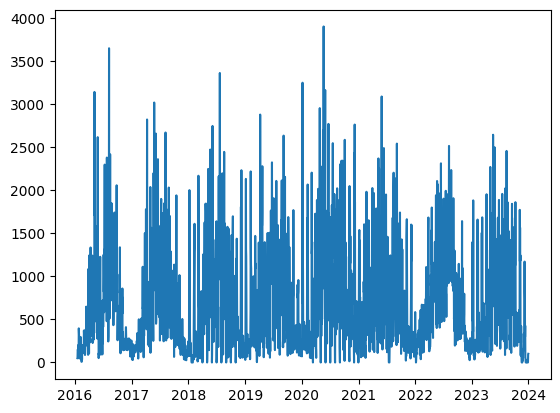

In [2]:
plt.plot(df['estermannufer'])

In [3]:
df.index = pd.to_datetime(df.index)
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

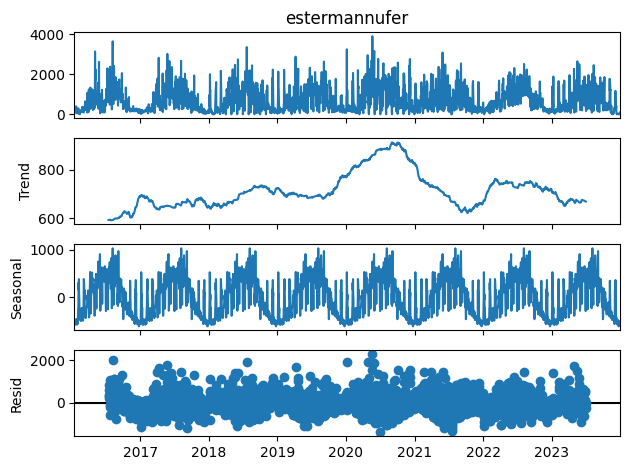

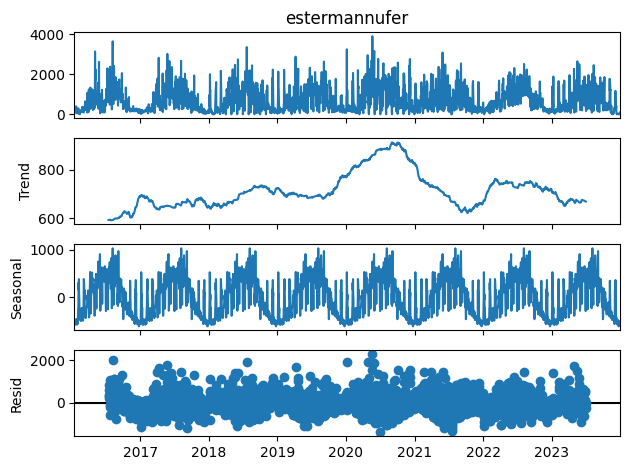

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df[header], period=365)
decomposition.plot()

In [5]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['estermannufer'])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -3.9433
p-value = 0.0017


In [6]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [7]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]

In [8]:
df_train.loc[:,'differences'] = df_train.loc[:,'estermannufer'].diff(periods=365)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_3976\2673430208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,'estermannufer'].diff(periods=365)


Test statistic = -7.2765
P-value = 0.0000


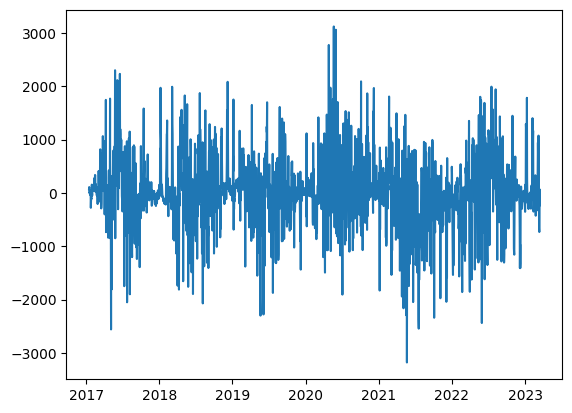

In [9]:
plt.plot(df_train.loc[:,'differences'] )

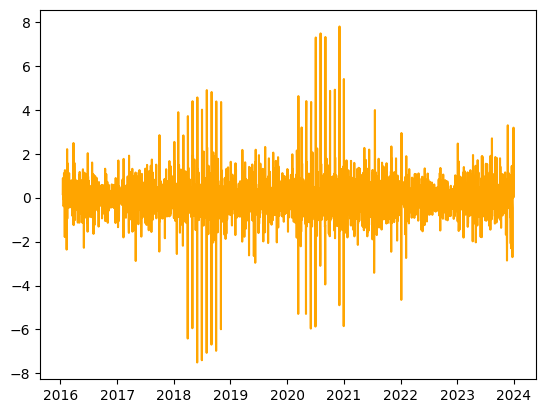

In [10]:
df['first_logged_diff'] = df['log'].diff().dropna()

plt.plot(df['first_logged_diff'], color='orange')
plt.show()

In [11]:
result = adfuller(df['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -22.9752
P-value = 0.0000


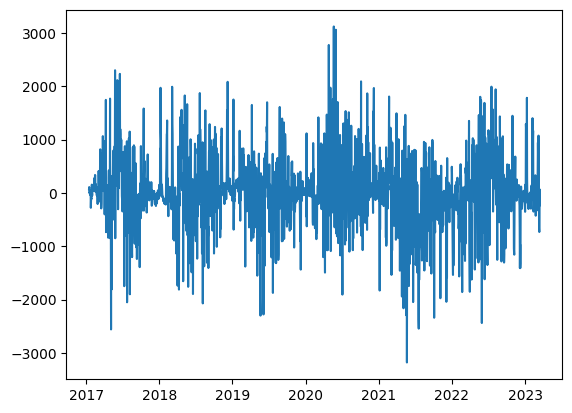

In [12]:
plt.plot(df_train['differences'])
plt.show()

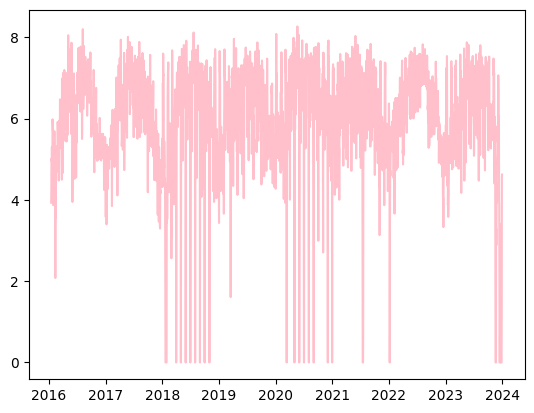

In [13]:
plt.plot(df['log'], color='pink')

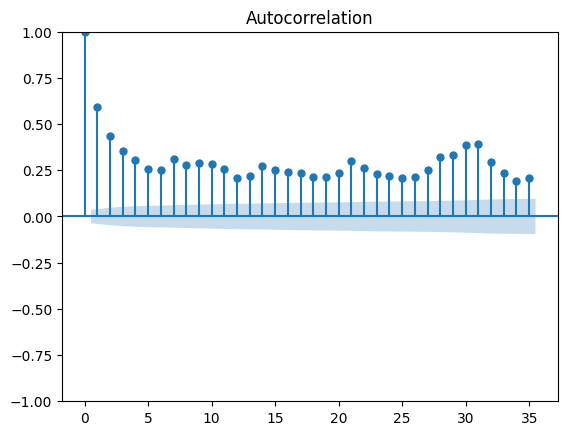

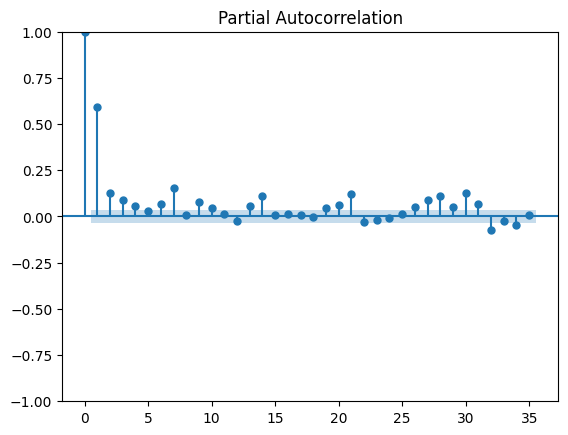

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df[header])
plot_pacf(df[header])
plt.show()

In [15]:
df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')
df_test = df_test.asfreq('D')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
#Log Likelyhood: hoch, AIC: niedrig

def ar_arima():
    for i in range(1, 3):
        p, d, q = i, 1, 0

        arima = SARIMAX(df_train['log'], order=(p, d, q), freq='D')
        result = arima.fit()
        print(result.summary())
        # Update des DataFrames
        df['differences'] = df_train['differences']
        model = SARIMAX(df['log'], order=(p, d, q), freq='D')
        result_new = model.filter(result.params)

        # Vorhersage
        predicted = result_new.predict(start=start_date)
        tmp = pd.DataFrame(predicted)
        tmp['crossings'] = tmp['predicted_mean']
        tmp.index = tmp.index.date
        tmp['crossings'] =  np.exp(tmp['crossings'])
        tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

        # Mergen der Daten
        df_r = pd.concat([df_train, tmp], axis=1)
        #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

        df_r[header] = df_r[header].fillna(df_r['crossings'])
        df_r = pd.DataFrame(df_r)
        df_r.index = pd.to_datetime(df_r.index)

        # Plotten
        plt.title('AR, Ordnung = {:.0f}'.format(i))
        plt.plot(df_r.loc[start_date:end_date, header],
             color='yellow', label='predicted')
        plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
        plt.legend()
        plt.show()

        y_pred_simple = df_test[header].iloc[:-1]
        y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
        y_pred_simple = y_pred_simple.sort_index().tolist()

        df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
        df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
        df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
        df_test.loc[:,'simple_predict'] = y_pred_simple

        greater = df_test[df_test['group'] == '> 10']
        mape_arima = []
        mape_simple = []

        for name, group in greater.groupby('intervals'):
            mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
            mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

        mae_arima = np.mean(np.abs(df_test[header] - predicted))
        mse_arima = np.mean(np.square(df_test[header] - predicted))
        mape_arima = sum(mape_arima)/len(mape_arima)
        mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
        mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
        mape_simple = sum(mape_simple)/len(mape_simple)

        print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
        print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
        print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

In [16]:
def ma_arima():
    for i in range(1, 3):
        p, d, q = i, 1, 0

        arima = SARIMAX(df_train['log'], order=(p, d, q), freq='D')
        result = arima.fit()
        print(result.summary())
        # Update des DataFrames
        df['differences'] = df_train['differences']
        model = SARIMAX(df['log'], order=(p, d, q), freq='D')
        result_new = model.filter(result.params)

        # Vorhersage
        predicted = result_new.predict(start=start_date)
        tmp = pd.DataFrame(predicted)
        tmp['crossings'] = tmp['predicted_mean']
        tmp.index = tmp.index.date
        tmp['crossings'] =  np.exp(tmp['crossings'])
        tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

        # Mergen der Daten
        df_r = pd.concat([df_train, tmp], axis=1)
        #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

        df_r[header] = df_r[header].fillna(df_r['crossings'])
        df_r = pd.DataFrame(df_r)
        df_r.index = pd.to_datetime(df_r.index)

        # Plotten
        plt.title('MA, Ordnung = {:.0f}'.format(i))
        plt.plot(df_r.loc[start_date:end_date, header],
             color='yellow', label='predicted')
        plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
        plt.legend()
        plt.show()

        y_pred_simple = df_test[header].iloc[:-1]
        y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
        y_pred_simple = y_pred_simple.sort_index().tolist()

        df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
        df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
        df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
        df_test.loc[:,'simple_predict'] = y_pred_simple

        greater = df_test[df_test['group'] == '> 10']
        mape_arima = []
        mape_simple = []

        for name, group in greater.groupby('intervals'):
            mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
            mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

        mae_arima = np.mean(np.abs(df_test[header] - predicted))
        mse_arima = np.mean(np.square(df_test[header] - predicted))
        mape_arima = sum(mape_arima)/len(mape_arima)
        mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
        mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
        mape_simple = sum(mape_simple)/len(mape_simple)

        print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
        print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
        print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                 2617
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -3557.919
Date:                Sat, 08 Feb 2025   AIC                           7119.838
Time:                        20:28:23   BIC                           7131.577
Sample:                    01-16-2016   HQIC                          7124.090
                         - 03-16-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2614      0.009    -29.144      0.000      -0.279      -0.244
sigma2         0.8889      0.008    109.573      0.000       0.873       0.905
Ljung-Box (L1) (Q):                   5.65   Jarque-

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


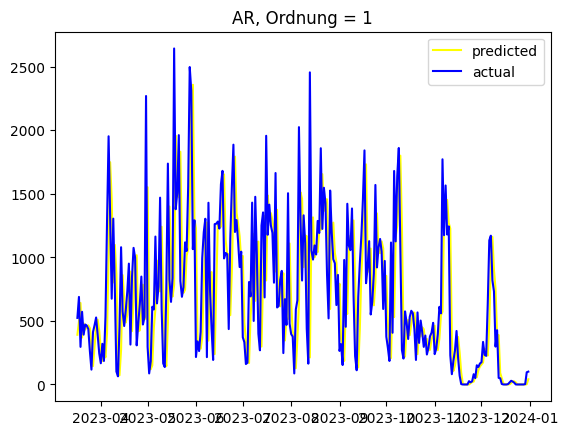

mean absolute error (mae): ARIMA: 723.4848, simple: 354.2379
mean squared error (mse): ARIMA: 829592.0558, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.6965, simple: 0.6210
                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                 2617
Model:               SARIMAX(2, 1, 0)   Log Likelihood               -3516.104
Date:                Sat, 08 Feb 2025   AIC                           7038.208
Time:                        20:28:29   BIC                           7055.816
Sample:                    01-16-2016   HQIC                          7044.586
                         - 03-16-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


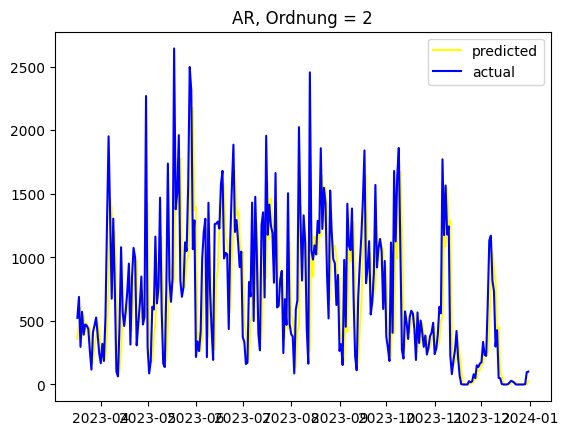

mean absolute error (mae): ARIMA: 723.5046, simple: 354.2379
mean squared error (mse): ARIMA: 829619.3207, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.7385, simple: 0.6210


In [17]:
for i in range(1, 3):
    p, d, q = i, 1, 0

    arima = SARIMAX(df_train['log'], order=(p, d, q), freq='D')
    result = arima.fit()
    print(result.summary())
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q), freq='D')
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start=start_date)
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    tmp['crossings'] =  np.exp(tmp['crossings'])
    tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r.loc[start_date:end_date, header],
         color='yellow', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test[header].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
    df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 10']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                 2617
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -3557.919
Date:                Sat, 08 Feb 2025   AIC                           7119.838
Time:                        20:28:40   BIC                           7131.577
Sample:                    01-16-2016   HQIC                          7124.090
                         - 03-16-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2614      0.009    -29.144      0.000      -0.279      -0.244
sigma2         0.8889      0.008    109.573      0.000       0.873       0.905
Ljung-Box (L1) (Q):                   5.65   Jarque-

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


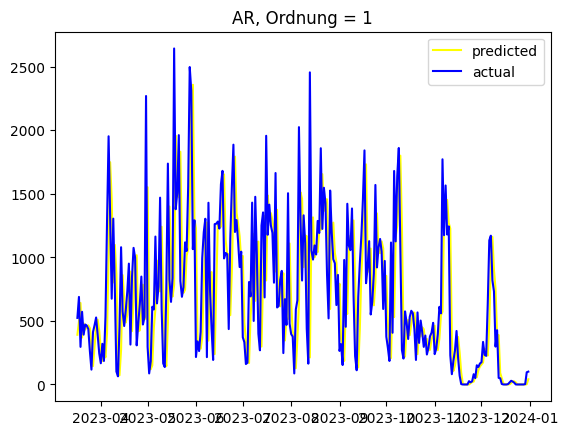

mean absolute error (mae): ARIMA: 723.4848, simple: 354.2379
mean squared error (mse): ARIMA: 829592.0558, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.6965, simple: 0.6210
                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                 2617
Model:               SARIMAX(2, 1, 0)   Log Likelihood               -3516.104
Date:                Sat, 08 Feb 2025   AIC                           7038.208
Time:                        20:28:44   BIC                           7055.816
Sample:                    01-16-2016   HQIC                          7044.586
                         - 03-16-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


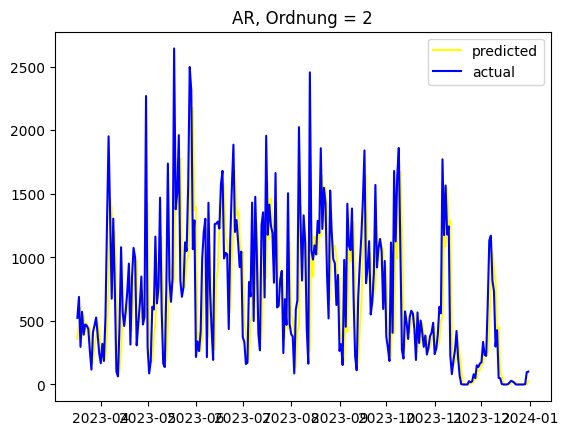

mean absolute error (mae): ARIMA: 723.5046, simple: 354.2379
mean squared error (mse): ARIMA: 829619.3207, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.7385, simple: 0.6210


In [18]:
ar_arima()

                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                 2617
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -3557.919
Date:                Sat, 08 Feb 2025   AIC                           7119.838
Time:                        20:28:49   BIC                           7131.577
Sample:                    01-16-2016   HQIC                          7124.090
                         - 03-16-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2614      0.009    -29.144      0.000      -0.279      -0.244
sigma2         0.8889      0.008    109.573      0.000       0.873       0.905
Ljung-Box (L1) (Q):                   5.65   Jarque-

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


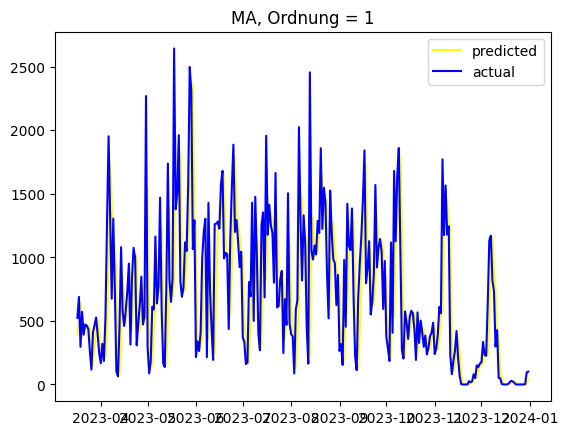

mean absolute error (mae): ARIMA: 723.4848, simple: 354.2379
mean squared error (mse): ARIMA: 829592.0558, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.6965, simple: 0.6210
                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                 2617
Model:               SARIMAX(2, 1, 0)   Log Likelihood               -3516.104
Date:                Sat, 08 Feb 2025   AIC                           7038.208
Time:                        20:28:51   BIC                           7055.816
Sample:                    01-16-2016   HQIC                          7044.586
                         - 03-16-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


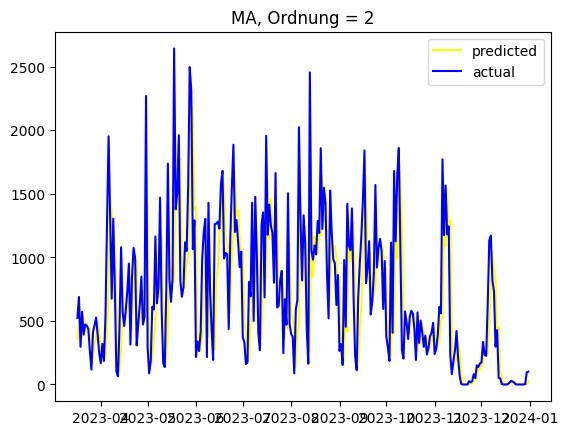

mean absolute error (mae): ARIMA: 723.5046, simple: 354.2379
mean squared error (mse): ARIMA: 829619.3207, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.7385, simple: 0.6210


In [19]:
ma_arima()

Seasonal ARIMA

In [20]:
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
df_unstack = df_unstack.unstack(['month'])
df_unstack

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,2932,4172,9020,18393,31823,11871,36468,40001,32755,13716,7687,6146
2017,4225,6486,17575,20038,31116,35957,34586,34693,20424,16800,9483,3641
2018,7996,10877,14350,26432,31915,26887,37570,31103,22918,20321,13140,13054
2019,12111,17733,14602,25150,24374,31811,30876,29963,22633,18624,11920,10706
2020,15159,13099,21576,32656,41642,34204,41801,33159,31453,20650,19603,18560
2021,15596,21085,22494,23068,25922,28282,16989,28018,28074,17412,12597,12876
2022,6945,8898,21790,21891,32388,33210,37666,41735,22851,20958,11899,5027
2023,10211,12756,15964,22248,32168,29708,26696,31986,26500,18233,11144,6573


In [21]:
df['days_noyear'] = pd.to_datetime(df.index).strftime('%m-%d')
df['day_mean'] = df.groupby('days_noyear')[header].transform('mean')
df['cleaned_by_mean'] = df['log'] - df['day_mean']
display(df)

,estermannufer,scaled,log,first_logged_diff,differences,days_noyear,day_mean,cleaned_by_mean
days,,,,,,,,
2016-01-16,50,50.987183,3.931574,NaN,NaN,01-16,220.125,-216.193426
2016-01-17,59,59.984876,4.094092,0.162518,NaN,01-17,138.875,-134.780908
2016-01-18,145,145.962830,4.983352,0.889260,NaN,01-18,194.375,-189.391648
2016-01-19,151,151.961292,5.023626,0.040274,NaN,01-19,150.500,-145.476374
2016-01-20,141,141.963855,4.955572,-0.068053,NaN,01-20,191.500,-186.544428
...,...,...,...,...,...,...,...,...
2023-12-27,0,1.000000,0.000000,0.000000,NaN,12-27,159.250,-159.250000
2023-12-28,0,1.000000,0.000000,0.000000,NaN,12-28,186.125,-186.125000
2023-12-29,3,3.999231,1.386102,1.386102,NaN,12-29,192.250,-190.863898


In [22]:
df['weekday'] = df.index.dayofweek  # 0 = Montag, 6 = Sonntag
weekly_pattern = df.groupby('weekday')[header].mean()
print(weekly_pattern)

weekday
0    650.330120
1    656.231325
2    671.108434
3    663.906024
4    649.320482
5    727.108173
6    899.747596
Name: estermannufer, dtype: float64


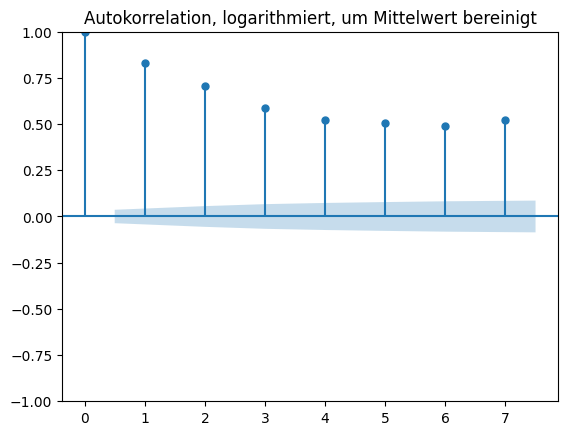

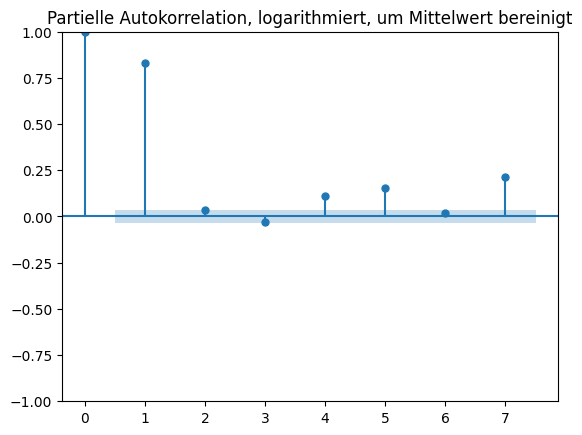

In [23]:
lags  = 7
plot_acf(df['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()
#für Order-Ebene, Lag 1 signifikant

In [24]:
'''
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
print(df_unstack)
'''

"\ndf_unstack = df[[header]]\ndf_unstack = df_unstack.set_index([df.index.year, df.index.month])\ndf_unstack.index.rename(['year', 'month'], inplace=True)\ndf_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())\nprint(df_unstack)\n"

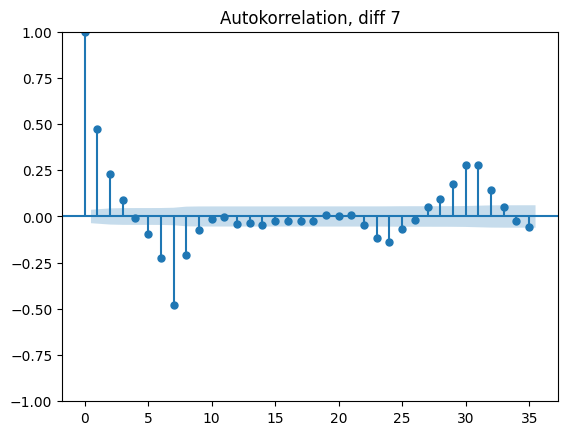

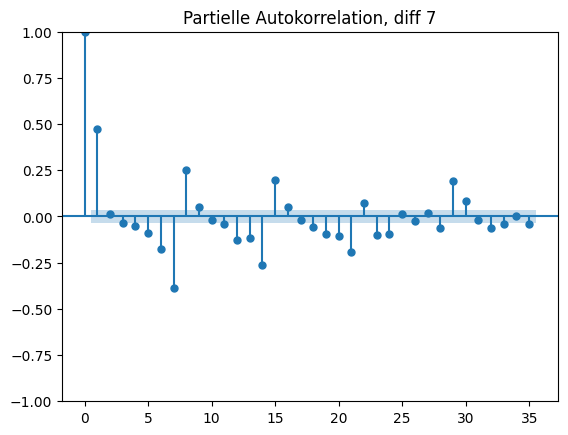

In [25]:
diffs = df[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [26]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df) * 0.8)
df_train_seas = df.iloc[:end_train]
df_test_seas = df.iloc[end_train:]

seasonal = 7
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python

ARIMA (0,0,0)x(0,1,0,7) LL -4197.8432, AIC: 8397.6864
ARIMA (0,1,0)x(0,1,0,7) LL -4081.6970, AIC: 8165.3940
ARIMA (1,0,0)x(0,1,1,7) LL -3106.4349, AIC: 6218.8698
ARIMA (1,0,0)x(0,1,2,7) LL -3100.7236, AIC: 6209.4473
ARIMA (1,1,0)x(0,1,2,7) LL -3257.9800, AIC: 6523.9600
ARIMA (0,0,1)x(0,1,2,7) LL -3276.1780, AIC: 6560.3559
ARIMA (0,1,1)x(0,1,2,7) LL -3211.2072, AIC: 6430.4144
ARIMA (0,1,1)x(2,1,0,7) LL -3495.8333, AIC: 6999.6666


In [28]:
print(result4.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                    log   No. Observations:                 2326
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 7)   Log Likelihood               -3100.724
Date:                                Sat, 08 Feb 2025   AIC                           6209.447
Time:                                        20:30:20   BIC                           6232.443
Sample:                                    01-16-2016   HQIC                          6217.828
                                         - 05-29-2022                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6279      0.009     73.462      0.000       0.611       0.645
ma.

In [29]:
results_final = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2022-05-30', end='2024-12-31')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)


C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


            predicted_mean    unlogged  new_predict
2022-05-30        6.183006  484.446249   483.570209
2022-05-31        6.175012  480.588778   479.711750
2022-06-01        6.292631  540.573490   539.711842
2022-06-02        6.115987  453.043139   452.159048
2022-06-03        6.148629  468.075422   467.195185
...                    ...         ...          ...
2024-12-27        6.092735  442.630430   441.743669
2024-12-28        6.199435  492.470736   491.596754
2024-12-29        6.296499  542.668957   541.807846
2024-12-30        6.100110  445.906637   445.020716
2024-12-31        6.128527  458.759964   457.877339

[947 rows x 3 columns]


Text(0.5, 1.0, 'Prognose')

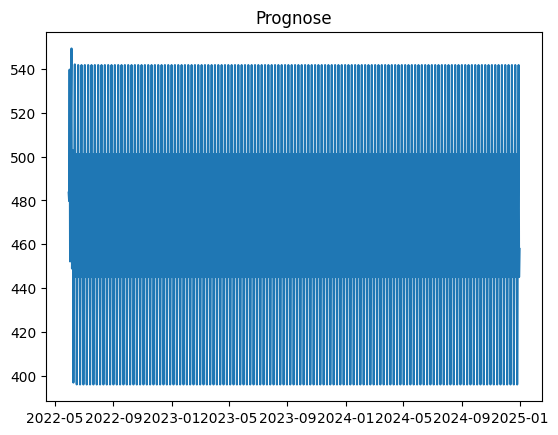

In [30]:
plt.plot(y_pred_no_update['new_predict'])
plt.title('Prognose')

Text(0.5, 1.0, 'tatsächliche Daten')

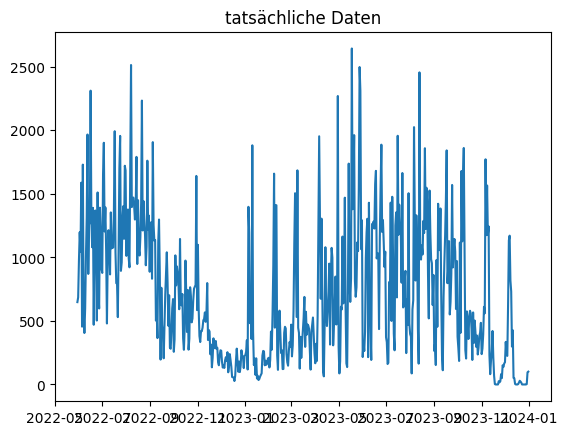

In [31]:
plt.plot(df_test_seas[header])
plt.title('tatsächliche Daten')

In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2022-05-30', end='2024-12-31')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,predicted_mean,unlogged,final_data
2022-05-30,6.183006,484.446249,483.570209
2022-05-31,6.358460,577.356352,576.504136
2022-06-01,6.516825,676.427447,675.600633
2022-06-02,6.488725,657.684140,656.852520
2022-06-03,6.759556,862.259113,861.479948
...,...,...,...
2024-12-27,6.025391,413.803477,412.909324
2024-12-28,6.045508,422.212114,421.320117
2024-12-29,6.146058,466.873296,465.992751
2024-12-30,6.020469,411.771652,410.876978


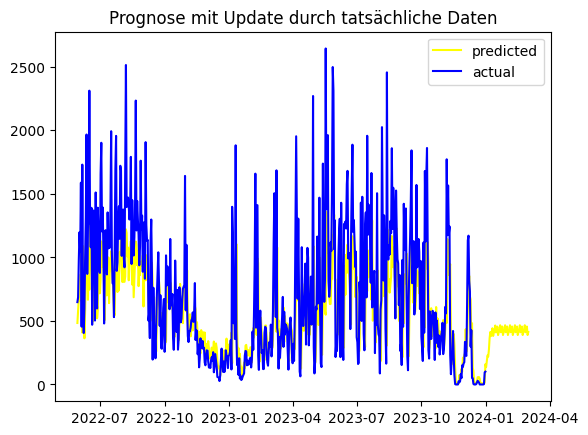

In [33]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-05-30'
end_date = '2024-03-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [34]:
df_r

,estermannufer,scaled,log,first_logged_diff,differences,days_noyear,day_mean,cleaned_by_mean,weekday,predicted_mean,unlogged,final_data
2016-01-16,50.000000,50.987183,3.931574,NaN,NaN,01-16,220.125,-216.193426,5.0,NaN,NaN,NaN
2016-01-17,59.000000,59.984876,4.094092,0.162518,NaN,01-17,138.875,-134.780908,6.0,NaN,NaN,NaN
2016-01-18,145.000000,145.962830,4.983352,0.889260,NaN,01-18,194.375,-189.391648,0.0,NaN,NaN,NaN
2016-01-19,151.000000,151.961292,5.023626,0.040274,NaN,01-19,150.500,-145.476374,1.0,NaN,NaN,NaN
2016-01-20,141.000000,141.963855,4.955572,-0.068053,NaN,01-20,191.500,-186.544428,2.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,412.909324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.025391,413.803477,412.909324
2024-12-28,421.320117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.045508,422.212114,421.320117
2024-12-29,465.992751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.146058,466.873296,465.992751
2024-12-30,410.876978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.020469,411.771652,410.876978


In [39]:
mape_bound = 100

df_test_seas.loc[:,'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:,'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mape_arima = sum(mape_arima)/len(mape_arima)


print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 294.6030
mean squared error (mse): ARIMA: 183656.8488
mean absolute percentage error (mape): ARIMA: 0.4270


In [107]:
df_month = df
df_month.set_index([df_month.index.year, df_month.index.month])
df_month['month'] = df_month.index.month
df_month['year'] = df_month.index.year
df_month = df_month.groupby(['year', 'month']).sum().reset_index()
monthly_pattern = df_month.groupby('month')[header].mean()
print(monthly_pattern)

month
1      9396.875
2     11888.250
3     17171.375
4     23734.500
5     31418.500
6     28991.250
7     32831.500
8     33832.250
9     25951.000
10    18339.250
11    12184.125
12     9572.875
Name: estermannufer, dtype: float64


In [108]:
df_month.index

RangeIndex(start=0, stop=96, step=1)

In [109]:
df_month['year-month'] = df_month['year'].astype(str) + "-" + df_month['month'].astype(str).str.zfill(2)
tmp = pd.DataFrame()
tmp['year-month'] =  df_month['year-month']
tmp[header] = df_month[header]
df_month = tmp

In [110]:
df_month['year-month'] = pd.to_datetime(df_month['year-month'])
df_month.index = df_month['year-month']
df_month

,year-month,estermannufer
year-month,,
2016-01-01,2016-01-01,2932
2016-02-01,2016-02-01,4172
2016-03-01,2016-03-01,9020
2016-04-01,2016-04-01,18393
2016-05-01,2016-05-01,31823
...,...,...
2023-08-01,2023-08-01,31986
2023-09-01,2023-09-01,26500
2023-10-01,2023-10-01,18233


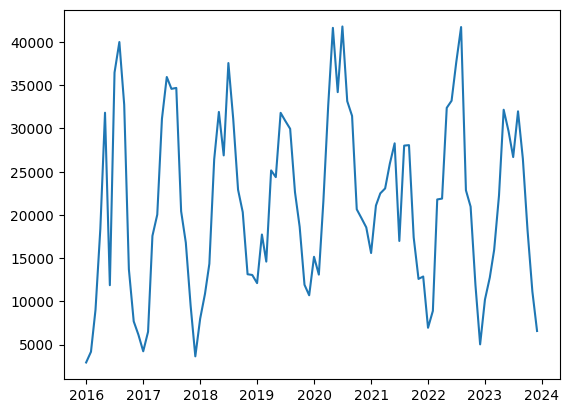

In [111]:
plt.plot(df_month[header])